In [2]:
import pandas as pd
ruta = "/home/alejo/Projects/University/Fundamentos-de-la-Ciencia-de-Datos/Archivos/obesity_1.csv"
df = pd.read_csv(ruta)
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


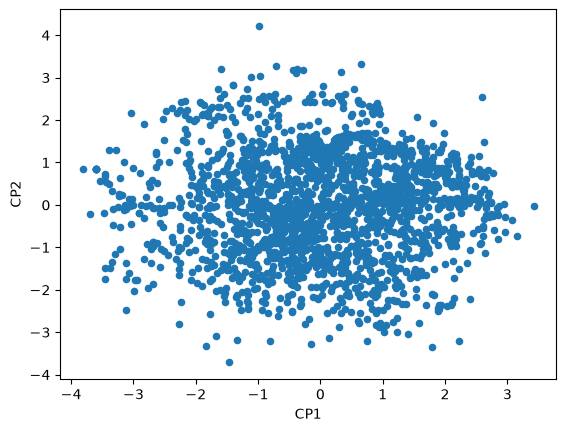

In [12]:
#PCA sobre variables cuantitativas.
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

variables_cuantitativas = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
df_cuantitativas = df[variables_cuantitativas]

#Estandarización de variables.
scaler = StandardScaler()
df_cuantitativas_escalado = scaler.fit_transform(df_cuantitativas)

#Aplicación de PCA.
pca = PCA(n_components=2)
df_cuantitativas_PCA = pca.fit_transform(df_cuantitativas_escalado)

#Conversión a DataFrame.
df_pca = pd.DataFrame(df_cuantitativas_PCA, columns=['CP1', 'CP2'])

#Grafico.
df_pca.plot(kind='scatter', x='CP1', y='CP2')
plt.show()

In [10]:
#Total de varianza explicada y ratio de varianza explicada por cada uno de los componentes.
print("Ratio de varianza explicada por cada componente: ", pca.explained_variance_ratio_)

total_varianza = pca.explained_variance_ratio_.sum()
print(f"El total de varianza explicada: {total_varianza*100:.2f}%")

Ratio de varianza explicada por cada componente:  [0.22648604 0.18657893]
El total de varianza explicada: 41.31%


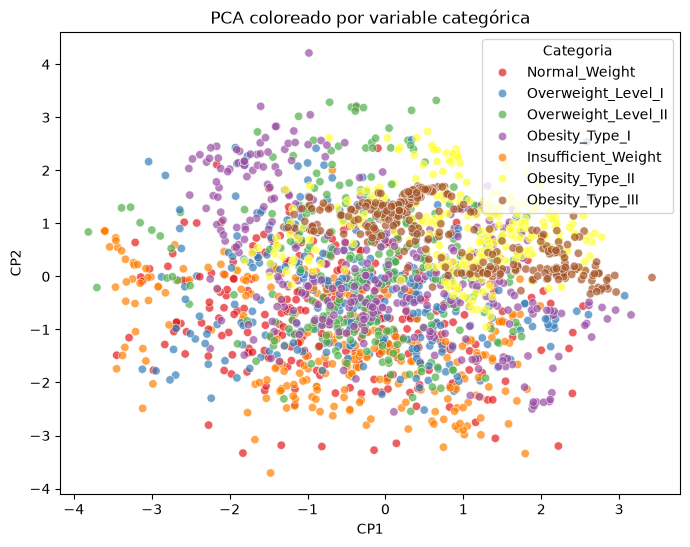

In [26]:
#Scatterplot de variable categorica.
import seaborn as sns
import matplotlib.pyplot as plt

# Agregamos las componentes principales a un DataFrame junto con una variable categórica de tu df original (ejemplo: 'Gender' o 'NObeyesdad')
df_pca['Categoria'] = df['NObeyesdad'] # (Cambiá esto por la variable categórica real de tu dataset)

# Graficamos con colores separados por esa categoría
plt.figure(figsize=(8, 6))
sns.scatterplot(x='CP1', y='CP2', hue='Categoria', data=df_pca, palette='Set1', alpha=0.7)
plt.title('PCA coloreado por variable categórica')
plt.show()

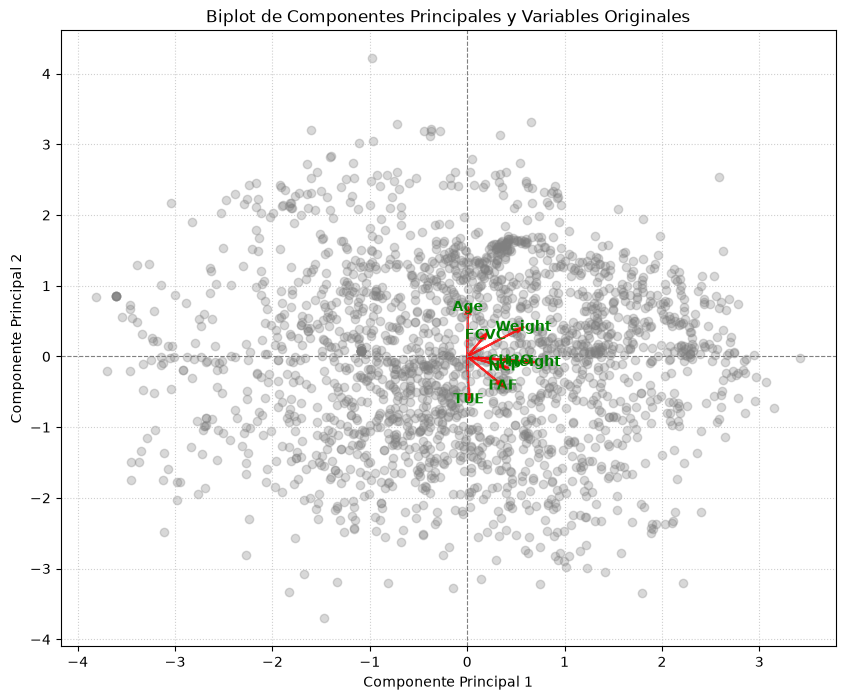

In [ ]:
#Representación de los dos componentes en una biplot.
import matplotlib.pyplot as plt
import numpy as np

loadings = pca.components_.T 

#Configuración del tamaño del gráfico
plt.figure(figsize=(10, 8))

#Graficar puntos de las muestras (scatter plot de componentes, anteriormente hecho)
plt.scatter(df_pca['CP1'], df_pca['CP2'], alpha=0.3, color='gray', label='Muestras')

#Dibujar las flechas y etiquetas para cada variable cuantitativa original
for i, var_name in enumerate(variables_cuantitativas):
    #Flechas desde origen hasta coordenadas del loading.
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='r', alpha=0.8, head_width=0.05, head_length=0.1, linewidth=1.5)
    #Nombre de la variable al final de la flecha.
    plt.text(loadings[i, 0] * 1.15, loadings[i, 1] * 1.15, var_name, color='g', ha='center', va='center', fontsize=10, weight='bold')

#Ejes x e y
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

#Formato del grafico.
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Biplot de Componentes Principales y Variables Originales')
plt.show()